# Ring Artifact & WF-Precorrected Image Generation
Converts artifact-free CT images into two derived datasets in one pass:
- **`ringartifact/FD_1mm/`** — ring artifact images (x_Ring)
- **`precorrected/FD_1mm/`** — WF-precorrected images (x_PRE)

Both are derived from the same ring-artifact sinogram p_Ring, so the WF
filter is applied in sinogram space where ring artifacts are vertical
stripes.

Pipeline (Chen et al. 2020, Fig. 1):
```
x_Free → Radon → p_Free × (1 + D_Norm) = p_Ring → FBP  → x_Ring
                                              └→ WF → FBP → x_PRE
```

In [2]:
!pip install -q pydicom pywavelets scikit-image tqdm numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.1 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import re, warnings
from pathlib import Path

import numpy as np
import pydicom
import pywt
from skimage.transform import radon, iradon
from tqdm import tqdm

warnings.filterwarnings('ignore', category=UserWarning)
print('Imports OK.')

Imports OK.


In [5]:
# ── Configuration ─────────────────────────────────────────────────────────────
BASE      = '/content/drive/MyDrive/medicalimaging'
SRC_ROOT  = f'{BASE}/artifactfree/FD_1mm'    # input:  artifact-free images
RING_ROOT = f'{BASE}/ringartifact/FD_1mm'    # output: ring artifact images
PRE_ROOT  = f'{BASE}/precorrected/FD_1mm'    # output: WF-precorrected images

# ── D_Norm / ring artifact parameters ─────────────────────────────────────────
N_RINGS    = 18     # number of rings per patient
TARGET_HU  = 100.0  # target ring amplitude in HU (each ring varies 40-160% of this)
MIN_OFFSET = 20     # min detector offset from centre (px) — rings start near centre
MAX_OFFSET = 235    # max detector offset from centre (px) — rings reach FOV edge
MIN_WIDTH  = 2      # min spike width in detector bins  — thinnest rings
MAX_WIDTH  = 12     # max spike width in detector bins  — thickest rings (tree-trunk bands)

# ── WF filter parameters (Münch et al. 2009 / Chen et al. 2020) ───────────────
WF_WAVELET = 'db5'  # Daubechies 5 (paper default)
WF_LEVEL   = 4      # decomposition depth T (paper default)
WF_SIGMA   = 4.0    # Gaussian damping width in frequency bins (paper default)

# ── Sinogram geometry ──────────────────────────────────────────────────────────
N_VIEWS  = 360
ANGLES   = np.linspace(0, 180, N_VIEWS, endpoint=False)
MU_WATER = 0.192    # linear attenuation of water at ~70 keV (cm⁻¹)

print('Configuration loaded.')
print(f'  Source : {SRC_ROOT}')
print(f'  Ring   : {RING_ROOT}')
print(f'  Pre    : {PRE_ROOT}')
print(f'  Rings per patient: {N_RINGS}, target {TARGET_HU} HU, '
      f'offset [{MIN_OFFSET}–{MAX_OFFSET}] px, width [{MIN_WIDTH}–{MAX_WIDTH}] bins')

Configuration loaded.
  Source : /content/drive/MyDrive/medicalimaging/artifactfree/FD_1mm
  Ring   : /content/drive/MyDrive/medicalimaging/ringartifact/FD_1mm
  Pre    : /content/drive/MyDrive/medicalimaging/precorrected/FD_1mm
  Rings per patient: 18, target 100.0 HU, offset [20–235] px, width [2–12] bins


In [6]:
# ── HU ↔ μ conversion ─────────────────────────────────────────────────────────

def hu_to_mu(hu):
    """HU → linear attenuation (cm⁻¹).  Air (−1000 HU) → 0 exactly."""
    return np.maximum(0.0, MU_WATER * (1.0 + hu / 1000.0))

def mu_to_hu(mu):
    return 1000.0 * (mu / MU_WATER - 1.0)

def apply_circle_mask(img):
    """
    Zero outside the radon(circle=True) reconstruction disc.
    1-pixel inset silences skimage's boundary warning and avoids edge artefacts.
    """
    H, W = img.shape
    cy, cx = H // 2, W // 2
    r = min(H, W) // 2 - 1
    Y, X = np.ogrid[:H, :W]
    out = img.copy()
    out[(X - cx)**2 + (Y - cy)**2 > r**2] = 0.0
    return out


# ── Radon / FBP ────────────────────────────────────────────────────────────────

def forward_project(mu):
    return radon(mu, theta=ANGLES, circle=True).astype(np.float64)

def back_project(sino):
    return iradon(sino, theta=ANGLES, circle=True,
                  filter_name='ramp').astype(np.float64)


# ── D_Norm calibration table ───────────────────────────────────────────────────
# K_fbp(offset): ring_HU ≈ D_gain × p_mean × K_fbp
# Extended to offsets 20–240 px so rings span the full body FOV.
_K_OFFSETS = np.array([20,   30,   40,   50,   75,   100,  125,  150,  175,  200,  220,  240])
_K_VALUES  = np.array([1800, 1100, 740,  546,  462,  390,  346,  316,  327,  552,  702,  702])


def make_D_Norm(p_free, patient_seed):
    """
    Build D_Norm as narrow spikes producing tree-trunk style concentric rings.

    Each spike at detector bin j → one ring at radius |j − centre| px.
    Rings vary in width (MIN_WIDTH–MAX_WIDTH bins) and amplitude (40–160% of TARGET_HU).
    """
    n_det  = p_free.shape[0]
    center = n_det // 2
    rng    = np.random.default_rng(patient_seed)
    D      = np.zeros(n_det, dtype=np.float64)

    offsets_used = []
    attempts = 0
    while len(offsets_used) < N_RINGS and attempts < 2000:
        attempts += 1
        offset  = int(rng.integers(MIN_OFFSET, MAX_OFFSET + 1))
        side    = int(rng.choice([-1, 1]))
        bin_pos = center + side * offset

        if not (0 <= bin_pos < n_det):
            continue
        if any(abs(bin_pos - b) < 3 for b in offsets_used):
            continue   # too close to an existing ring

        p_mean = float(p_free[bin_pos].mean())
        if p_mean < 0.3:
            continue   # air-only projection — ring would be invisible

        K    = float(np.interp(offset, _K_OFFSETS, _K_VALUES))
        gain = (TARGET_HU * rng.uniform(0.4, 1.6)) / (p_mean * K)
        w    = int(rng.integers(MIN_WIDTH, MAX_WIDTH + 1))
        amp  = gain * float(rng.choice([-1.0, 1.0]))
        D[bin_pos : min(bin_pos + w, n_det)] = amp
        offsets_used.append(bin_pos)

    return D


# ── WF precorrection ───────────────────────────────────────────────────────────

def wf_precorrect(sino, wavelet=WF_WAVELET, level=WF_LEVEL, sigma=WF_SIGMA):
    """
    Wavelet-Fourier precorrection applied to the ring-artifact sinogram p_Ring.

    skimage radon returns (n_detbins, n_views) where ring
    artifacts are HORIZONTAL stripes (constant across views).  The WF algorithm
    expects (n_views, n_detbins) where they are VERTICAL stripes in the c_v band.

    Steps (Münch et al. 2009 / Chen et al. 2020):
      1. Transpose → (n_views, n_detbins)
      2. 2D wavelet decomposition → stripe energy in c_v
      3. Column-wise 1D FFT along axis=0 (views) → stripes → DC at n̂=0
      4. Gaussian damping: g(n̂) = 1 − exp(−n̂²/2σ²)
      5. Inverse FFT + inverse 2D DWT → p_PRE (transposed)
      6. Transpose back → (n_detbins, n_views)
    """
    sino_T = sino.T.astype(np.float64)
    orig   = sino_T.shape
    coeffs     = pywt.wavedec2(sino_T, wavelet=wavelet, level=level)
    new_coeffs = [coeffs[0]]
    for k in range(1, len(coeffs)):
        cH, cV, cD = coeffs[k]
        n      = cV.shape[0]
        cV_fft = np.fft.fftshift(np.fft.fft(cV, axis=0), axes=0)
        n_hat  = np.arange(-(n // 2), -(n // 2) + n, dtype=np.float64)
        g      = (1.0 - np.exp(-(n_hat**2) / (2.0 * sigma**2)))[:, None]
        cV_f   = np.real(np.fft.ifft(
            np.fft.ifftshift(cV_fft * g, axes=0), axis=0))
        new_coeffs.append((cH, cV_f, cD))
    out_T = pywt.waverec2(new_coeffs, wavelet=wavelet)
    return out_T[:orig[0], :orig[1]].T.astype(np.float64)


# ── DICOM I/O ──────────────────────────────────────────────────────────────────

def load_dicom_hu(path):
    ds        = pydicom.dcmread(str(path))
    slope     = float(getattr(ds, 'RescaleSlope',     1.0))
    intercept = float(getattr(ds, 'RescaleIntercept', 0.0))
    return ds, ds.pixel_array.astype(np.float64) * slope + intercept

def save_dicom_hu(ds_template, new_hu, out_path):
    slope     = float(getattr(ds_template, 'RescaleSlope',     1.0))
    intercept = float(getattr(ds_template, 'RescaleIntercept', 0.0))
    stored    = np.round((new_hu - intercept) / slope).astype(np.int16)
    nd = ds_template.copy()
    nd.PixelData           = stored.tobytes()
    nd.Rows                = stored.shape[0]
    nd.Columns             = stored.shape[1]
    nd.BitsAllocated       = 16
    nd.BitsStored          = 16
    nd.HighBit             = 15
    nd.PixelRepresentation = 1
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    nd.save_as(str(out_path))

def patient_seed(path):
    for part in Path(path).parts:
        m = re.match(r'^L(\d+)$', part, re.IGNORECASE)
        if m: return int(m.group(1))
    return abs(hash(Path(path).parent.name)) % (2**31)

def glob_ima(root):
    seen = set(); files = []
    for pat in ('*.ima', '*.IMA', '*.dcm', '*.DCM'):
        for f in Path(root).rglob(pat):
            if f not in seen: seen.add(f); files.append(f)
    return sorted(files)

print('All functions defined.')

All functions defined.


In [7]:
# ── Resume check: find already-processed files ────────────────────────────────
# If the notebook is interrupted and restarted, images that already exist in
# both output folders are skipped so work is not repeated.

src_files  = glob_ima(SRC_ROOT)
if not src_files:
    raise FileNotFoundError(
        f'No .IMA files found under {SRC_ROOT}\n'
        f'Check that the Drive path is correct and files are uploaded.')

print(f'Artifact-free images found: {len(src_files)}')

# Identify which source files still need processing
todo = []
already_done = 0
for src in src_files:
    rel        = src.relative_to(SRC_ROOT)
    ring_out   = Path(RING_ROOT) / rel
    pre_out    = Path(PRE_ROOT)  / rel
    # Try .IMA extension swap in case outputs used different case
    def exists_either(p):
        return p.exists() or p.with_suffix(p.suffix.swapcase()).exists()
    if exists_either(ring_out) and exists_either(pre_out):
        already_done += 1
    else:
        todo.append(src)

print(f'Already done : {already_done}')
print(f'Still to do  : {len(todo)}')
if not todo:
    print('\nAll images already processed. Nothing to do.')
else:
    print(f'Starting from: {todo[0].name}')

Artifact-free images found: 5936
Already done : 5520
Still to do  : 416
Starting from: L506_FD_1_1.CT.0002.0111.2015.12.22.20.19.52.894480.358592454.IMA


In [8]:
# ── Main processing loop ──────────────────────────────────────────────────────
d_cache = {}   # patient_seed → D_Norm  (one per patient, shared across slices)

for ima_path in tqdm(todo, desc='Generating images', unit='img'):
    seed = patient_seed(ima_path)
    rel  = ima_path.relative_to(SRC_ROOT)

    ds, hu_free = load_dicom_hu(ima_path)
    mu_free     = apply_circle_mask(hu_to_mu(hu_free))

    # ── Forward project → p_Free ──────────────────────────────────────────
    p_free = forward_project(mu_free)

    # ── Build D_Norm once per patient ─────────────────────────────────────
    # All slices of the same patient share the same D_Norm
    if seed not in d_cache:
        d_cache[seed] = make_D_Norm(p_free, seed)
    D = d_cache[seed]

    # ── Inject ring artifacts → p_Ring (Chen et al. Eq. 4) ───────────────
    p_ring = p_free * (1.0 + D[:, np.newaxis])

    # ── FBP(p_Ring) → x_Ring ─────────────────────────────────────────────
    hu_ring = mu_to_hu(np.maximum(0.0, back_project(p_ring)))
    hu_ring = np.clip(hu_ring, hu_free.min() - 300, hu_free.max() + 300)
    save_dicom_hu(ds, hu_ring, Path(RING_ROOT) / rel)

    # ── WF(p_Ring) → p_PRE → FBP → x_PRE ────────────────────────────────
    # WF is applied directly to p_Ring (sinogram)
    p_pre  = wf_precorrect(p_ring)
    hu_pre = mu_to_hu(np.maximum(0.0, back_project(p_pre)))
    hu_pre = np.clip(hu_pre, hu_free.min() - 300, hu_free.max() + 300)
    save_dicom_hu(ds, hu_pre, Path(PRE_ROOT) / rel)

print(f'\nDone. {len(todo)} image pairs written.')
print(f'  Ring artifact : {RING_ROOT}')
print(f'  Precorrected  : {PRE_ROOT}')

Generating images: 100%|██████████| 416/416 [53:05<00:00,  7.66s/img]


Done. 416 image pairs written.
  Ring artifact : /content/drive/MyDrive/medicalimaging/ringartifact/FD_1mm
  Precorrected  : /content/drive/MyDrive/medicalimaging/precorrected/FD_1mm


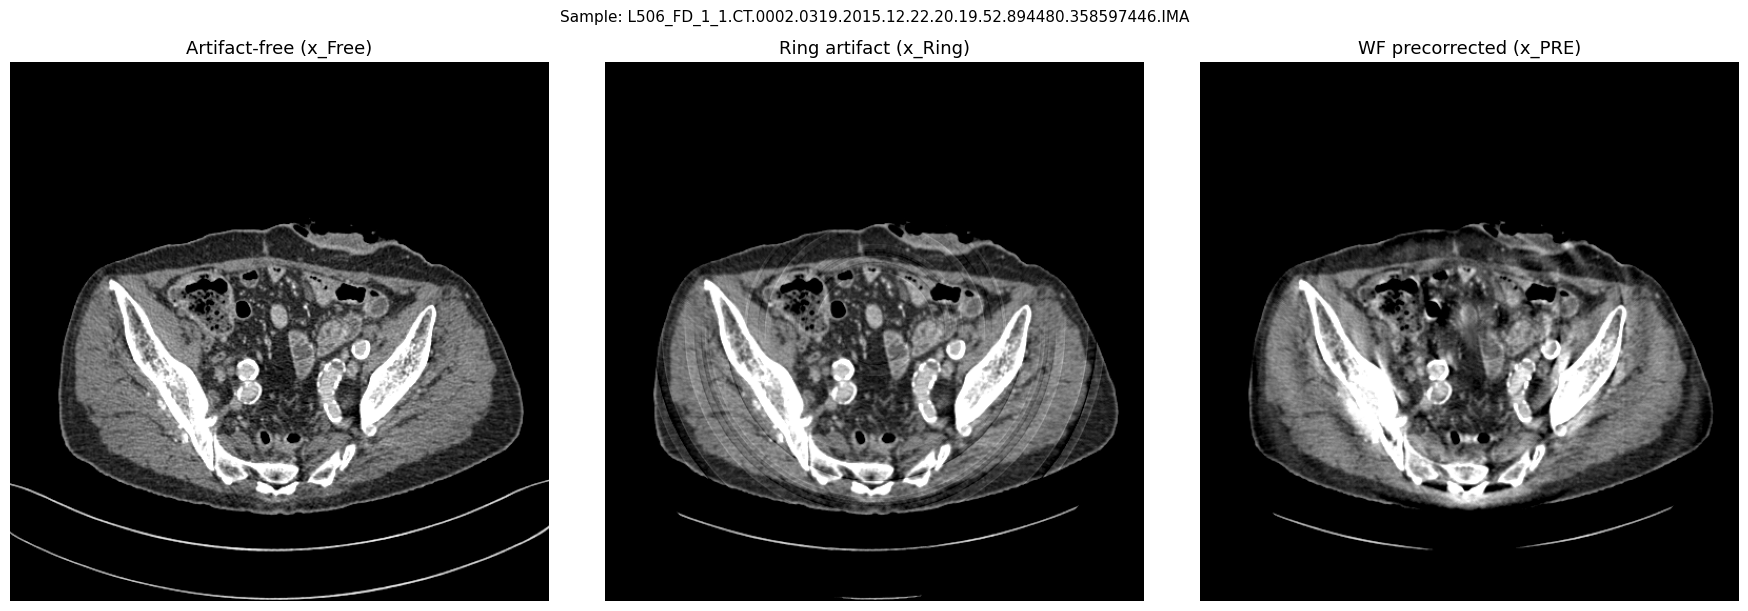

Visual check complete.


In [9]:
# ── Quick visual check — sample one image from the last processed patient ────
import matplotlib.pyplot as plt

if todo:
    sample = todo[len(todo) // 2]   # pick a middle slice
    rel    = sample.relative_to(SRC_ROOT)

    _, hu_free = load_dicom_hu(sample)
    _, hu_ring = load_dicom_hu(Path(RING_ROOT) / rel)
    _, hu_pre  = load_dicom_hu(Path(PRE_ROOT)  / rel)

    wl, ww = 55, 440    # standard abdomen window
    vmin, vmax = wl - ww//2, wl + ww//2

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    titles = ['Artifact-free (x_Free)', 'Ring artifact (x_Ring)', 'WF precorrected (x_PRE)']
    for ax, img, title in zip(axes, [hu_free, hu_ring, hu_pre], titles):
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=13)
        ax.axis('off')

    plt.suptitle(f'Sample: {sample.name}', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()
    print('Visual check complete.')
else:
    print('Nothing new was processed — all images were already done.')